In [13]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('data/jena_cleaned.csv', index_col='Date Time', parse_dates=True)

print(df.shape)
df.head()

(420551, 14)


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2009-01-01 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
2009-01-01 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2009-01-01 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
2009-01-01 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
2009-01-01 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [14]:
# Select features
features = ['T (degC)', 'p (mbar)', 'Tdew (degC)', 'rh (%)', 
            'VPact (mbar)', 'VPdef (mbar)', 'wv (m/s)', 'wd (deg)']

df = df[features]

# Drop rows with NaN
df = df.dropna()

print(f"Shape after feature selection and NaN removal: {df.shape}")

Shape after feature selection and NaN removal: (420533, 8)


In [15]:
# Cyclical encoding for wind direction
df['wd_sin'] = np.sin(2 * np.pi * df['wd (deg)'] / 360)
df['wd_cos'] = np.cos(2 * np.pi * df['wd (deg)'] / 360)
df = df.drop(columns=['wd (deg)'])

# Cyclical encoding for time features
df['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)
df['doy_sin'] = np.sin(2 * np.pi * df.index.dayofyear / 365)
df['doy_cos'] = np.cos(2 * np.pi * df.index.dayofyear / 365)

print(f"Shape after encoding: {df.shape}")
print(df.head())

Shape after encoding: (420533, 13)
                     T (degC)  p (mbar)  Tdew (degC)  rh (%)  VPact (mbar)  \
Date Time                                                                    
2009-01-01 00:10:00     -8.02    996.52        -8.90    93.3          3.11   
2009-01-01 00:20:00     -8.41    996.57        -9.28    93.4          3.02   
2009-01-01 00:30:00     -8.51    996.53        -9.31    93.9          3.01   
2009-01-01 00:40:00     -8.31    996.51        -9.07    94.2          3.07   
2009-01-01 00:50:00     -8.27    996.51        -9.04    94.1          3.08   

                     VPdef (mbar)  wv (m/s)    wd_sin    wd_cos  hour_sin  \
Date Time                                                                   
2009-01-01 00:10:00          0.22      1.03  0.464842 -0.885394       0.0   
2009-01-01 00:20:00          0.21      0.72  0.693402 -0.720551       0.0   
2009-01-01 00:30:00          0.20      0.19  0.146083 -0.989272       0.0   
2009-01-01 00:40:00          0.19

In [16]:
# chronological split
n = len(df)

train_size = int(n * 0.70) 
val_size   = int(n * 0.15) 
test_size  = n - train_size - val_size  

train_df = df[:train_size]
val_df   = df[train_size:train_size + val_size]
test_df  = df[train_size + val_size:]

print(f"Total rows: {n}")
print(f"Train size: {train_size} ({train_size/n*100:.1f}%)")
print(f"Val size:   {val_size} ({val_size/n*100:.1f}%)")
print(f"Test size:  {test_size} ({test_size/n*100:.1f}%)")
print()
print(f"Train: {train_df.index[0]} to {train_df.index[-1]}")
print(f"Val:   {val_df.index[0]} to {val_df.index[-1]}")
print(f"Test:  {test_df.index[0]} to {test_df.index[-1]}")

Total rows: 420533
Train size: 294373 (70.0%)
Val size:   63079 (15.0%)
Test size:  63081 (15.0%)

Train: 2009-01-01 00:10:00 to 2014-08-05 00:20:00
Val:   2014-08-05 00:30:00 to 2015-10-17 20:20:00
Test:  2015-10-17 20:30:00 to 2017-01-01 00:00:00


In [17]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_df)
val_scaled   = scaler.transform(val_df)
test_scaled  = scaler.transform(test_df)

print(f"Train mean: {train_scaled.mean():.4f}")
print(f"Train std: {train_scaled.std():.4f}")

Train mean: 0.4610
Train std: 0.3185


In [18]:
print("Train T (degC) original range:", train_df['T (degC)'].min(), "to", train_df['T (degC)'].max())
print("Val T (degC) original range:", val_df['T (degC)'].min(), "to", val_df['T (degC)'].max())
print()
print("Train scaled T range:", train_scaled[:, 0].min(), "to", train_scaled[:, 0].max())
print("Val scaled T range:", val_scaled[:, 0].min(), "to", val_scaled[:, 0].max())
print()
print("Train log1p(scaled T) range:", np.log1p(train_scaled[:, 0]).min(), "to", np.log1p(train_scaled[:, 0]).max())
print("Val log1p(scaled T) range:", np.log1p(val_scaled[:, 0]).min(), "to", np.log1p(val_scaled[:, 0]).max())

Train T (degC) original range: -23.01 to 35.86
Val T (degC) original range: -8.32 to 37.28

Train scaled T range: 0.0 to 1.0
Val scaled T range: 0.24953286903346356 to 1.0241209444538815

Train log1p(scaled T) range: 0.0 to 0.6931471805599453
Val log1p(scaled T) range: 0.22276977669595033 to 0.7051355048049116


In [19]:
def create_sequences(data, window_size, forecast_horizon, target_col=0):
    X, y = [], []
    for i in range(len(data) - window_size - forecast_horizon):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size+forecast_horizon, target_col])
    return np.array(X), np.array(y)

# steps = hours x (60minutes/10min) = hours x 6 
window_size = 72 # 12 hours = 12 x 6 = 72 steps
forecast_horizon = 144 # 24 hours = 24 x 6 = 144 steps

X_train, y_train = create_sequences(train_scaled, window_size, forecast_horizon)
X_val, y_val = create_sequences(val_scaled, window_size, forecast_horizon)
X_test, y_test = create_sequences(test_scaled, window_size, forecast_horizon)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (294157, 72, 13), y_train shape: (294157,)
X_val shape: (62863, 72, 13), y_val shape: (62863,)
X_test shape: (62865, 72, 13), y_test shape: (62865,)


In [20]:
from keras.models import Sequential
from keras.layers import SimpleRNN, LSTM, Dense

def rmsle(y_true, y_pred):
    return tf.sqrt(tf.reduce_mean(tf.square(tf.math.log1p(y_pred) - tf.math.log1p(y_true))))

model_rnn = Sequential([
    SimpleRNN(32, input_shape=(window_size, X_train.shape[2])),
    Dense(1)
])

model_rnn.compile(optimizer='adam', loss='mse', metrics=[rmsle])
model_rnn.summary()

/home/jagfoljersolen/APPROF/deep-learning-cnn-rnn-isep/venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,505 (5.88 KB)

 Trainable params: 1,505 (5.88 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history_rnn = model_rnn.fit(
    X_train, y_train,
    epochs=10,
    batch_size=256,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/10


W0000 00:00:1781094926.154037    8323 cpu_allocator_impl.cc:82] Allocation of 1101323808 exceeds 10% of free system memory.


1150/1150 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step - loss: 0.0149 - rmsle: nan - val_loss: 0.0029 - val_rmsle: 0.0487
Epoch 2/10
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 25s 22ms/step - loss: 0.0028 - rmsle: 0.1317 - val_loss: 0.0027 - val_rmsle: 0.0471
Epoch 3/10
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 23s 20ms/step - loss: 0.0027 - rmsle: 0.1318 - val_loss: 0.0028 - val_rmsle: 0.0474
Epoch 4/10
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 24s 21ms/step - loss: 0.0027 - rmsle: 0.1318 - val_loss: 0.0027 - val_rmsle: 0.0474
Epoch 5/10
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 25s 22ms/step - loss: 0.0027 - rmsle: 0.1319 - val_loss: 0.0026 - val_rmsle: 0.0467
Epoch 6/10
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 25s 22ms/step - loss: 0.0026 - rmsle: 0.1320 - val_loss: 0.0025 - val_rmsle: 0.0476
Epoch 7/10
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 25s 22ms/step - loss: 0.0026 - rmsle: 0.1320 - val_loss: 0.0025 - val_rmsle: 0.0466
Epoch 8/10
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 25s 22ms/step - loss: 0.0026 - rmsle: 0.1320 - val_loss: 0.0026 - val_rmsle: 0.0480
Epoch 

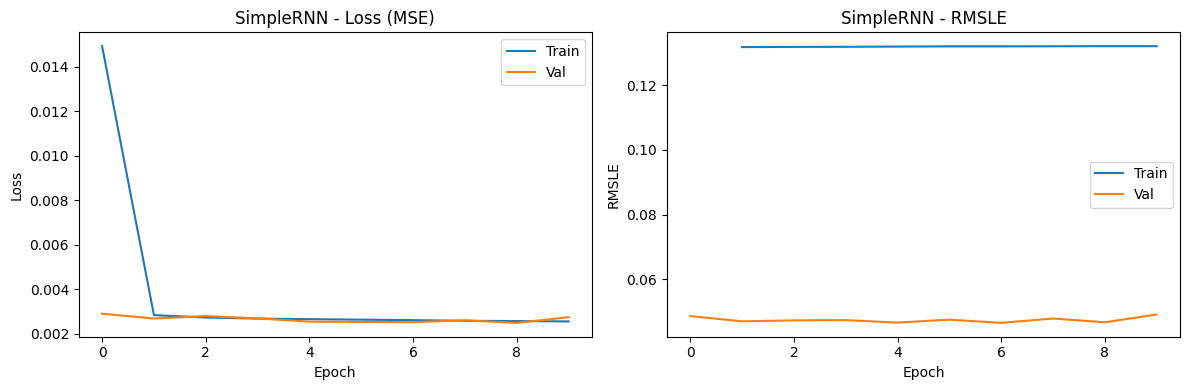

In [22]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_rnn.history['loss'], label='Train')
plt.plot(history_rnn.history['val_loss'], label='Val')
plt.title('SimpleRNN - Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_rnn.history['rmsle'], label='Train')
plt.plot(history_rnn.history['val_rmsle'], label='Val')
plt.title('SimpleRNN - RMSLE')
plt.xlabel('Epoch')
plt.ylabel('RMSLE')
plt.legend()

plt.tight_layout()
plt.show()

In [23]:
test_loss, test_rmsle = model_rnn.evaluate(X_test, y_test)
print("SimpleRNN Evaluation on Test Set:")
print(f"Test Loss: {test_loss:.4f}, Test RMSLE: {test_rmsle:.4f}")

1965/1965 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 0.0026 - rmsle: 0.0318
SimpleRNN Evaluation on Test Set:
Test Loss: 0.0026, Test RMSLE: 0.0318


In [24]:
# LSTM - window size 72
model_lstm = Sequential([
    LSTM(32, input_shape=(window_size, X_train.shape[2])),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse', metrics=[rmsle])
model_lstm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         5,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,921 (23.13 KB)

 Trainable params: 5,921 (23.13 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=10,
    batch_size=256,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/10


W0000 00:00:1781097847.132858    8323 cpu_allocator_impl.cc:82] Allocation of 1101323808 exceeds 10% of free system memory.


1150/1150 ━━━━━━━━━━━━━━━━━━━━ 77s 65ms/step - loss: 0.0049 - rmsle: 0.1328 - val_loss: 0.0026 - val_rmsle: 0.0475
Epoch 2/10
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 75s 65ms/step - loss: 0.0026 - rmsle: 0.1320 - val_loss: 0.0025 - val_rmsle: 0.0471
Epoch 3/10
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 76s 66ms/step - loss: 0.0025 - rmsle: 0.1321 - val_loss: 0.0026 - val_rmsle: 0.0478
Epoch 4/10
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 77s 67ms/step - loss: 0.0025 - rmsle: 0.1321 - val_loss: 0.0025 - val_rmsle: 0.0464
Epoch 5/10
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 75s 65ms/step - loss: 0.0025 - rmsle: 0.1321 - val_loss: 0.0026 - val_rmsle: 0.0477
Epoch 6/10
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 76s 66ms/step - loss: 0.0024 - rmsle: 0.1321 - val_loss: 0.0027 - val_rmsle: 0.0488
Epoch 7/10
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 76s 66ms/step - loss: 0.0024 - rmsle: 0.1322 - val_loss: 0.0025 - val_rmsle: 0.0469
Epoch 8/10
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 80s 70ms/step - loss: 0.0024 - rmsle: 0.1322 - val_loss: 0.0025 - val_rmsle: 0.0460
Epo

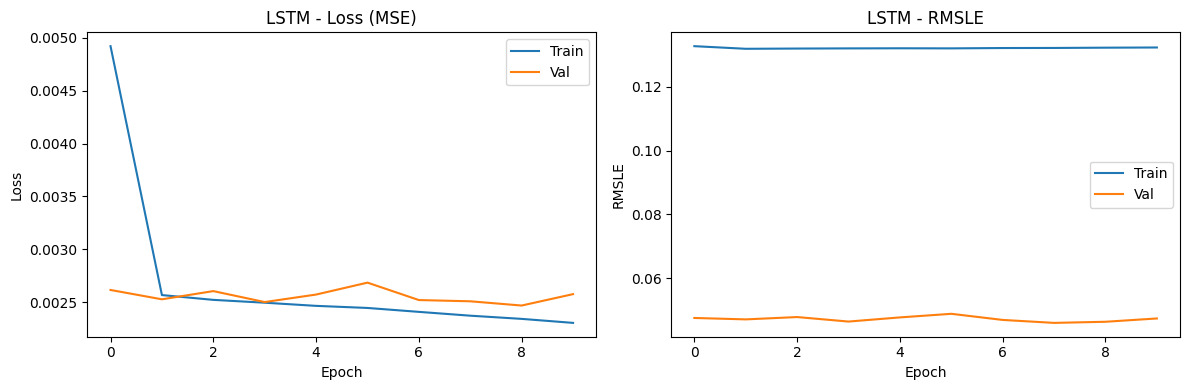

In [26]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_lstm.history['loss'], label='Train')
plt.plot(history_lstm.history['val_loss'], label='Val')
plt.title('LSTM - Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_lstm.history['rmsle'], label='Train')
plt.plot(history_lstm.history['val_rmsle'], label='Val')
plt.title('LSTM - RMSLE')
plt.xlabel('Epoch')
plt.ylabel('RMSLE')
plt.legend()

plt.tight_layout()
plt.show()

In [28]:
test_loss, test_rmsle = model_lstm.evaluate(X_test, y_test)
print("LSTM Evaluation on Test Set:")
print(f"Test Loss: {test_loss:.4f}, Test RMSLE: {test_rmsle:.4f}")

1965/1965 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - loss: 0.0024 - rmsle: 0.0304
LSTM Evaluation on Test Set:
Test Loss: 0.0024, Test RMSLE: 0.0304
